# 02 — Indicateurs cliniques et prévalence

Objectif : calculer la prévalence du diabète et de l'hypertension, et explorer les indicateurs cliniques (IMC, tension, HbA1c).

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt

from etl import build_patient_dataset

df = build_patient_dataset('../data/synthea_output')
df.head()

,patient_id,full_name,gender,birth_date,city,state,deceased,age,diabetes,hypertension,bmi,diastolic_bp,glucose,hba1c,systolic_bp,risk_score,risk_category
0,6ecc1038-51fc-4c3d-847a-f22d6a1ed4f5,Marc Rakoto,male,1959-09-11,Fianarantsoa,Haute Matsiatra,False,66,False,False,24.7,76.0,107.0,5.8,140.0,5,modéré
1,d2a4005b-fae9-4ebc-b9a8-b0115edcbe3c,Hanta Rasoa,female,1959-12-14,Antsirabe,Vakinankaratra,False,66,False,False,26.0,81.0,96.0,5.9,135.0,5,modéré
2,65de1645-7f3e-49d6-992a-c1c1e9d6f5a1,Fetra Rasoa,male,1978-10-02,Mahajanga,Boeny,False,47,True,True,27.3,81.0,133.0,7.1,148.0,11,élevé
3,2ffa3ba3-4945-4fbb-865e-f9ad3fb9755b,Fara Raza,female,1964-01-02,Toliara,Atsimo-Andrefana,False,62,False,False,24.7,76.0,100.0,5.5,135.0,3,faible
4,4f5781ca-3763-4a28-987f-80252fccfdd5,Rado Rakoto,male,1964-12-02,Mahajanga,Boeny,False,61,False,True,24.4,84.0,95.0,5.6,143.0,6,modéré


In [2]:
prevalence_diabete = 100 * df['diabetes'].mean()
prevalence_hta = 100 * df['hypertension'].mean()
comorbidite = 100 * (df['diabetes'] & df['hypertension']).mean()

print(f"Prévalence diabète : {prevalence_diabete:.1f}%")
print(f"Prévalence hypertension : {prevalence_hta:.1f}%")
print(f"Comorbidité (les deux) : {comorbidite:.1f}%")

Prévalence diabète : 23.3%
Prévalence hypertension : 34.0%
Comorbidité (les deux) : 8.7%


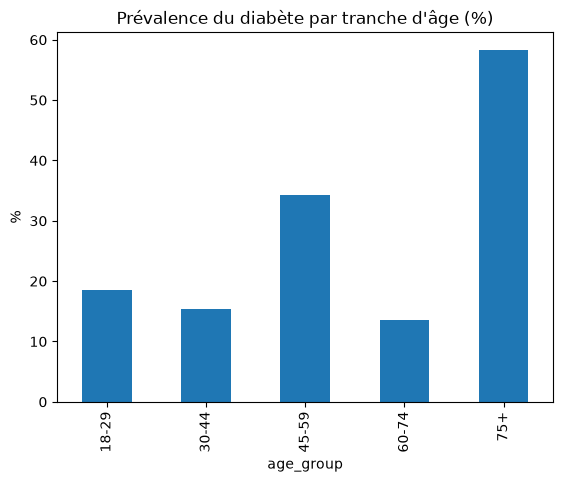

In [3]:
prevalence_by_age = df.assign(
    age_group=pd.cut(df['age'], bins=[18,30,45,60,75,120],
                      labels=['18-29','30-44','45-59','60-74','75+'])
).groupby('age_group')['diabetes'].mean() * 100

prevalence_by_age.plot(kind='bar', title='Prévalence du diabète par tranche d\'âge (%)')
plt.ylabel('%')
plt.show()

In [4]:
df[['bmi','systolic_bp','diastolic_bp','hba1c','glucose']].describe()

,bmi,systolic_bp,diastolic_bp,hba1c,glucose
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,25.859333,134.880000,80.206667,6.008667,108.360000
std,2.845345,11.792342,6.019316,0.783893,17.416447
min,20.500000,111.000000,69.000000,5.200000,84.000000
25%,23.825000,126.000000,76.000000,5.500000,97.000000
50%,25.600000,134.000000,79.500000,5.700000,102.500000
75%,27.775000,141.750000,84.000000,6.000000,115.750000
max,33.400000,163.000000,94.000000,7.700000,150.000000


## Observations

- **Prévalence du diabète : 23,3 %** et **prévalence de l'hypertension : 34,0 %** dans la cohorte — des taux volontairement élevés dans ce jeu de données synthétique afin de bien illustrer les mécanismes de segmentation du risque.
- Le taux de **comorbidité (diabète + hypertension) est de 8,7 %** : une part non négligeable des patients cumule les deux pathologies, ce qui justifie une approche de risque combinée plutôt qu'une analyse pathologie par pathologie.
- La prévalence du diabète **augmente nettement avec l'âge** : de 18,5 % chez les 18-29 ans, elle atteint 34,3 % chez les 45-59 ans et **58,3 % chez les 75 ans et plus** — cette tendance est cohérente avec la littérature clinique standard et valide la logique du score de risque basé sur l'âge.
- Les indicateurs cliniques moyens (IMC 25,9, tension systolique 134,9 mmHg, HbA1c 6,0 %) se situent globalement en zone de "pré-risque" plutôt qu'en zone pathologique franche, ce qui est attendu pour une population générale plutôt qu'une cohorte de patients déjà hospitalisés.